# Multistory Floor Classification

## Set Up Environment

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

from scenario2_utils import (
    DEFAULT_SEED,
    load_dataset_artifacts,
    plot_floor_colored_positions,
    print_floor_classification_metrics,
    set_random_seeds,
 )

set_random_seeds(DEFAULT_SEED)

## Load Data and Build Summary Features

In [2]:
dataset = load_dataset_artifacts(include_floor_indices=True)
csi_freq_domain_train = dataset.csi_freq_domain_train
groundtruth_positions_train = dataset.groundtruth_positions_train
groundtruth_floor_indices = dataset.groundtruth_floor_indices
floor_nr = dataset.floor_nr
ue_heights = dataset.ue_heights

print("Shape of csi_freq_domain_train: ", csi_freq_domain_train.shape)
print("Shape of groundtruth_positions_train: ", groundtruth_positions_train.shape)
print("Number of floors: {}".format(floor_nr))
print(ue_heights)

Shape of csi_freq_domain_train:  (5000, 5, 4, 2, 4, 64)
Shape of groundtruth_positions_train:  (5000, 3)
Number of floors: 5
[ 1.5   5.65  9.8  13.95 18.1 ]


## Cluster Floors with K-Means

In [3]:
channel_chart_positions_baseline = np.load('results/channel_chart_positions_baseline_transformed.npy')

In [4]:
est_floor_indices_kmeans_cc = KMeans(n_clusters=floor_nr, n_init="auto", max_iter=300, tol=1e-4, random_state=DEFAULT_SEED).fit_predict(channel_chart_positions_baseline[:, 2:3])

In [5]:
print_floor_classification_metrics(est_floor_indices_kmeans_cc, groundtruth_floor_indices)

Number of errors: 3010
Error rate: 60.2%
Adjusted Rand Index (ARI): 0.9846570870352815
Normalized Mutual Information (NMI): 0.978423347331638


60.2

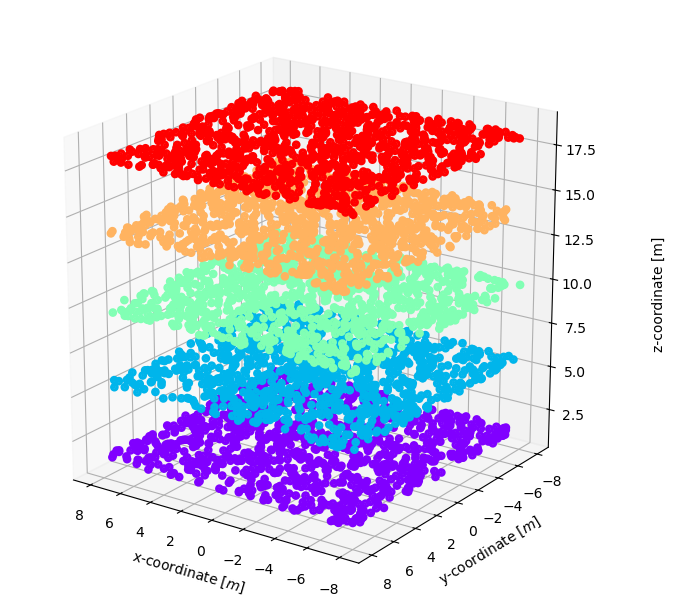

In [6]:
plot_floor_colored_positions(
    groundtruth_positions_train,
    groundtruth_positions_train,
    est_floor_indices_kmeans_cc,
    ue_heights,
    title=None,
    alpha=1.0,
 )

## Estimate Absolute Floors

### Map Relative Clusters to Absolute Floors

In [7]:
mean_magnitudes_by_floor = np.mean(np.abs(csi_freq_domain_train), axis=(2, 3, 4, 5))
est_floor_indices_max_mean_magnitude_by_floor = np.argmax(mean_magnitudes_by_floor, axis=1)

map_estimated_to_true_floor = np.asarray(
    [
        np.argmax(
            np.bincount(
                est_floor_indices_max_mean_magnitude_by_floor[est_floor_indices_kmeans_cc == floor_index],
                minlength=floor_nr,
            )
        )
        for floor_index in range(floor_nr)
    ],
    dtype=np.int32,
 )

In [8]:
est_absolute_floor_indices = map_estimated_to_true_floor[est_floor_indices_kmeans_cc]
np.save("results/est_absolute_floor_indices.npy", est_absolute_floor_indices)

In [9]:
print_floor_classification_metrics(est_absolute_floor_indices, groundtruth_floor_indices)

Number of errors: 31
Error rate: 0.62%
Adjusted Rand Index (ARI): 0.9846570870352815
Normalized Mutual Information (NMI): 0.978423347331638


0.62

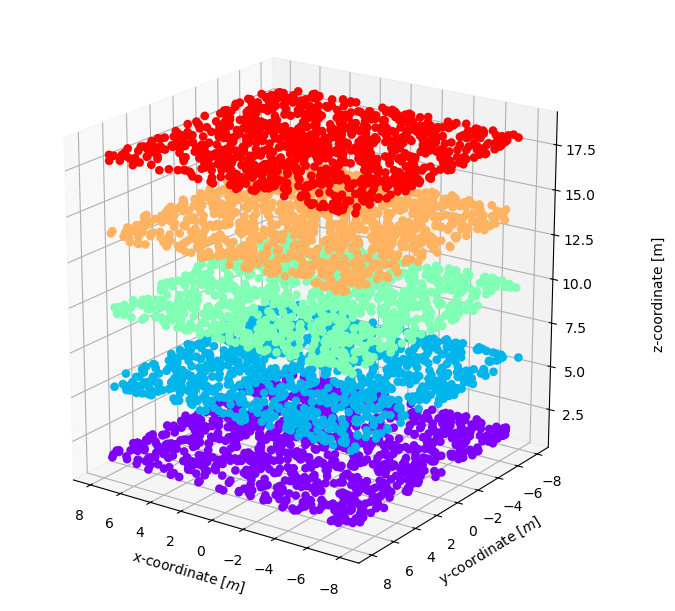

In [10]:
plot_floor_colored_positions(
    groundtruth_positions_train,
    groundtruth_positions_train,
    est_absolute_floor_indices,
    ue_heights,
    title=None,
    alpha=1.0,
    save_path="results/estimated_floor_indices_baseline.png",
 )

## Inspect Final Classification Results

### Confusion Matrix

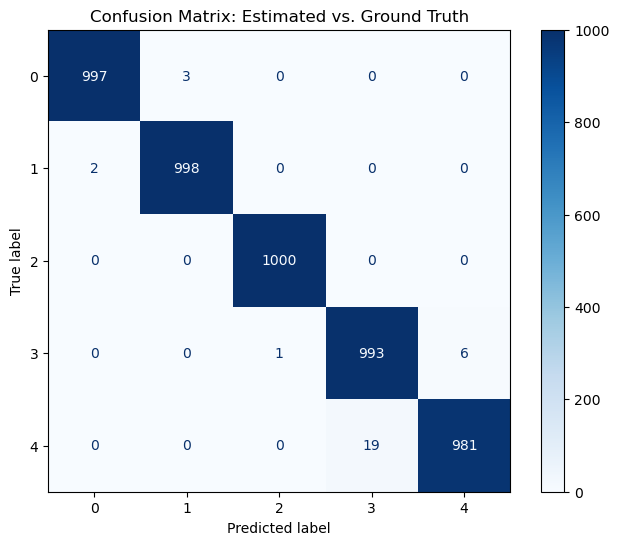

In [11]:
confusion_matrix_est_absolute_floor_indices = confusion_matrix(groundtruth_floor_indices, est_absolute_floor_indices)

# visualize confusion matrix
cmd = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_est_absolute_floor_indices)

fig, ax = plt.subplots(figsize=(8, 6))
cmd.plot(ax=ax, cmap='Blues', values_format='d') # 'd' ensures integers, avoiding the LaTeX bug

ax.set_title("Confusion Matrix: Estimated vs. Ground Truth")
plt.show()

### Classification Report

In [12]:
report = classification_report(groundtruth_floor_indices, est_absolute_floor_indices)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1000
           1       1.00      1.00      1.00      1000
           2       1.00      1.00      1.00      1000
           3       0.98      0.99      0.99      1000
           4       0.99      0.98      0.99      1000

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000

